<a href="https://colab.research.google.com/github/lawrancesahayasundar-tech/my_first_repo/blob/main/ml_leakage_pipeline1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Set random seed for reproducibility
np.random.seed(42)

# Create synthetic dataset (50 records)
n = 50
area_sqft = np.random.randint(500, 3000, n)
num_bedrooms = np.random.randint(1, 5, n)
age_years = np.random.randint(0, 30, n)

# Create target with some realistic relation + noise
price_lakhs = (
    area_sqft * 0.05 +
    num_bedrooms * 10 -
    age_years * 0.3 +
    np.random.normal(0, 5, n)
)

# Create DataFrame
df = pd.DataFrame({
    'area_sqft': area_sqft,
    'num_bedrooms': num_bedrooms,
    'age_years': age_years,
    'price_lakhs': price_lakhs
})

# Features and target
X = df[['area_sqft', 'num_bedrooms', 'age_years']]
y = df['price_lakhs']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build model
model = LinearRegression()
model.fit(X_train, y_train)

# Print intercept and coefficients
print("Intercept:", model.intercept_)
print("Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef}")

# Predictions
y_pred = model.predict(X_test)

# Compare actual vs predicted (first 5)
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print("\nFirst 5 Actual vs Predicted values:")
print(comparison.head())

Intercept: -2.485969759804746
Coefficients:
area_sqft: 0.05070538140437285
num_bedrooms: 10.175084796564267
age_years: -0.31583856880158656

First 5 Actual vs Predicted values:
       Actual   Predicted
0   99.601685   97.506081
1  171.800858  174.648709
2   57.703050   62.975292
3  126.676978  131.415141
4  107.554617  104.823929


In [2]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation Metrics:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

# Explanation:
# MAE shows the average absolute difference between predicted and actual prices.
# RMSE penalizes larger errors more strongly, indicating how spread out errors are.
# R² indicates how well the model explains the variance (closer to 1 means better fit).


Model Evaluation Metrics:
MAE: 3.01966298250043
RMSE: 3.446400463599782
R² Score: 0.9908689982020378


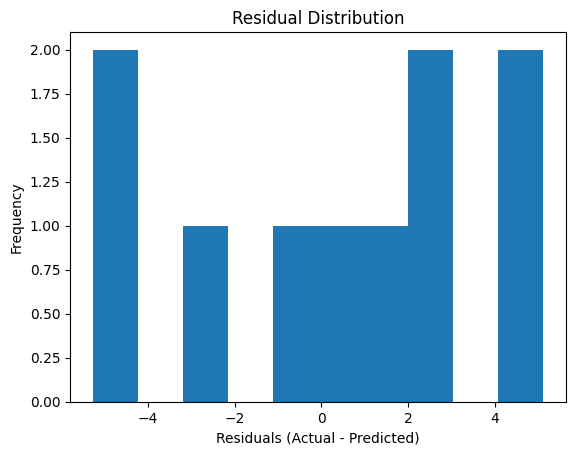

In [3]:
import matplotlib.pyplot as plt

# Compute residuals
residuals = y_test - y_pred

# Plot histogram
plt.hist(residuals, bins=10)
plt.title("Residual Distribution")
plt.xlabel("Residuals (Actual - Predicted)")
plt.ylabel("Frequency")
plt.show()

# Explanation:
# Residual = Actual value - Predicted value.
# If residuals are normally distributed around zero, the model is well-fitted.
# A skewed or wide distribution suggests bias or poor model performance.